In [2]:
import torch
from sklearn.datasets import make_regression

x,y = make_regression(
    n_samples=1000,
    n_features=5,
    noise =0.1,
    random_state=42
)

In [5]:
x[:5],y[:5]

(array([[ 2.05654356,  0.60685059,  0.48268789, -1.13088844,  0.42009449],
        [-0.79919201, -0.64596418, -0.18289644, -0.48274352,  1.37487642],
        [ 1.07600714, -0.79602586, -0.75196933,  0.02131165, -0.31905394],
        [-0.10325476, -0.82849702,  1.48986344, -1.64318881, -1.60090398],
        [-2.06340315,  0.50325206, -0.64557207, -0.31735049, -1.66108342]]),
 array([ 74.90561313, -41.64958796, -24.18286622, -87.09450463,
        -86.12202944]))

In [6]:
import matplotlib.pyplot as plt

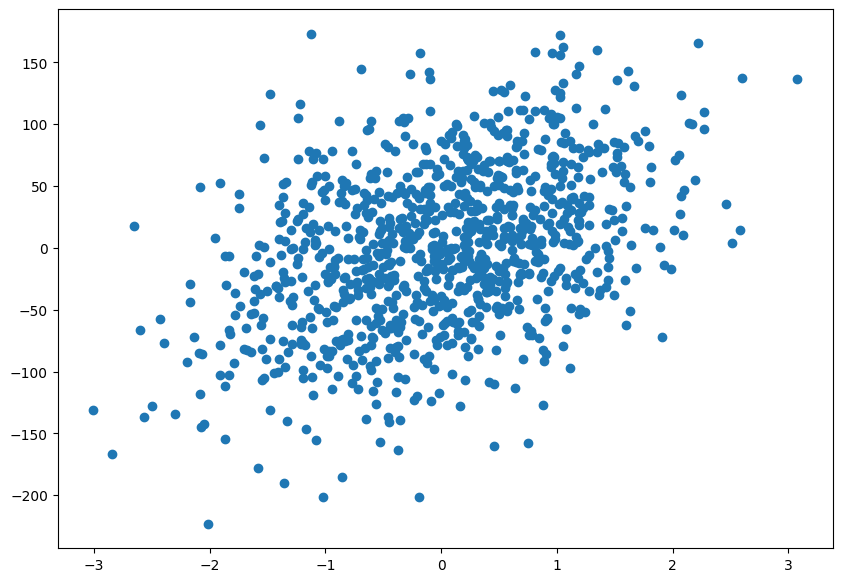

In [7]:
plt.figure(figsize=(10,7))
plt.scatter(x[:,0],y)
plt.show()

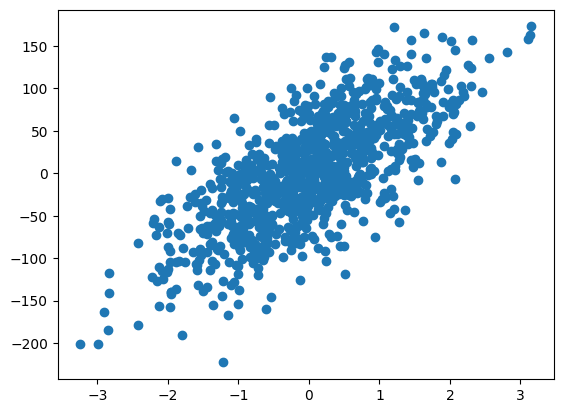

In [8]:
plt.scatter(x[:,1],y)
plt.show()

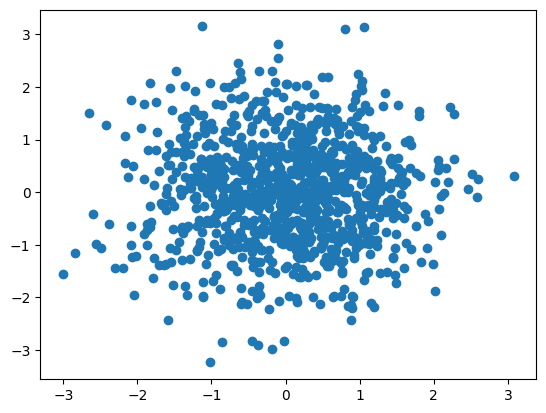

In [9]:
plt.scatter(x[:,0],x[:,1])
plt.show()

In [10]:
x_tensor = torch.tensor(x)
y_tensor = torch.tensor(y)

In [20]:
x_tensor.dtype, y_tensor.dtype

(torch.float64, torch.float64)

In [22]:
x_tensor = x_tensor.float()
y_tensor = y_tensor.float()

In [11]:
import torch.nn as nn

In [18]:
class LinearRegressionV1(nn.Module):
  def __init__(self):
    super(LinearRegressionV1, self).__init__()
    self.linear = nn.Linear(5,1)

  def forward(self,x):
    y_pred = self.linear(x)
    return y_pred

In [31]:
model = LinearRegressionV1()
with torch.inference_mode():
  y_pred = model(x_tensor[:5]).float()
  print(y_pred), print(y_tensor[:5])

tensor([[ 0.4623],
        [-0.7367],
        [ 0.2815],
        [-0.9269],
        [-0.3284]])
tensor([ 74.9056, -41.6496, -24.1829, -87.0945, -86.1220])


In [13]:
from sklearn.model_selection import train_test_split

In [27]:
x_train,x_test,y_train,y_test = train_test_split(x_tensor,y_tensor,test_size=0.2,random_state=42)

In [41]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.Adam(params=model.parameters(),lr=0.01)

In [44]:
torch.manual_seed(42)

# Reshape y_train and y_test to match model output [batch_size, 1]
y_train_reshaped = y_train.unsqueeze(dim=1)
y_test_reshaped = y_test.unsqueeze(dim=1)

for i in range(2000):
  model.train()

  y_preds = model(x_train)
  loss = loss_fn(y_preds,y_train_reshaped)
  train_loss = loss.item()
  if i % 10 == 0:
    print(f"Loss: {train_loss}")
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model.eval()
  with torch.inference_mode():
    test_preds = model(x_test)
    test_loss = loss_fn(test_preds,y_test_reshaped)
    if i % 10 == 0:
        print(f"Test Loss: {test_loss}")

Loss: 0.6017292141914368
Test Loss: 0.5830996036529541
Loss: 0.523409366607666
Test Loss: 0.5064924359321594
Loss: 0.44568249583244324
Test Loss: 0.42917510867118835
Loss: 0.3686884939670563
Test Loss: 0.35322874784469604
Loss: 0.29257702827453613
Test Loss: 0.2780872583389282
Loss: 0.21796655654907227
Test Loss: 0.20697210729122162
Loss: 0.14855583012104034
Test Loss: 0.14221593737602234
Loss: 0.09754612296819687
Test Loss: 0.09575582295656204
Loss: 0.08126101642847061
Test Loss: 0.08525191247463226
Loss: 0.08264918625354767
Test Loss: 0.08713001012802124
Loss: 0.08210019022226334
Test Loss: 0.08638720214366913
Loss: 0.08115355670452118
Test Loss: 0.0853789746761322
Loss: 0.08103305101394653
Test Loss: 0.08510866016149521
Loss: 0.08102113008499146
Test Loss: 0.08514814078807831
Loss: 0.08099780976772308
Test Loss: 0.08519074320793152
Loss: 0.08099549263715744
Test Loss: 0.08520206809043884
Loss: 0.08100572228431702
Test Loss: 0.08522732555866241
Loss: 0.0810069739818573
Test Loss: 0.0

In [36]:
print(model.state_dict())

OrderedDict({'linear.weight': tensor([[ 0.3419,  0.3712, -0.1048,  0.4108, -0.0980]]), 'linear.bias': tensor([0.0902])})


In [46]:
def plot_predictions(train_data=x_train,
                     train_labels=y_train,
                     test_data=x_test,
                     test_labels=y_test,
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

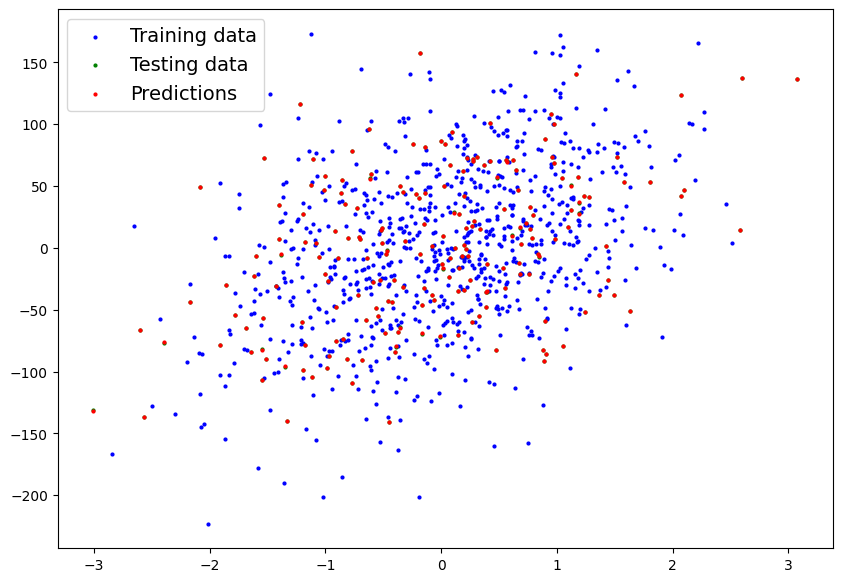

In [48]:
plot_predictions(train_data=x_train[:, 0], test_data=x_test[:, 0], predictions=test_preds.squeeze())